In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from tqdm import tqdm
import random
from collections import defaultdict

# Фиксируем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
print(f'PyTorch: {torch.__version__}, torchvision: {torchvision.__version__}')

Устройство: cpu
PyTorch: 2.10.0+cpu, torchvision: 0.25.0+cpu


In [10]:
# Трансформации
transform_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка данных
train_base = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_base)
train_aug = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_aug)
train_resnet = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_resnet)
test_dataset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_base)

# Разделение на train/val
train_size = int(0.8 * len(train_base))
val_size = len(train_base) - train_size

train_base, val_base = random_split(train_base, [train_size, val_size])
train_aug, val_aug = random_split(train_aug, [train_size, val_size])
train_resnet, val_resnet = random_split(train_resnet, [train_size, val_size])

# Для валидации используем базовый transform
val_base.dataset.transform = transform_base
val_aug.dataset.transform = transform_base

# DataLoader'ы
batch_size = 64
train_loader_base = DataLoader(train_base, batch_size=batch_size, shuffle=True)
train_loader_aug = DataLoader(train_aug, batch_size=batch_size, shuffle=True)
train_loader_resnet = DataLoader(train_resnet, batch_size=batch_size, shuffle=True)
val_loader_base = DataLoader(val_base, batch_size=batch_size, shuffle=False)
val_loader_aug = DataLoader(val_aug, batch_size=batch_size, shuffle=False)
val_loader_resnet = DataLoader(val_resnet, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train: {train_size}, Val: {val_size}, Test: {len(test_dataset)}')
print(f'Классы: {train_base.dataset.classes}')

Train: 4000, Val: 1000, Test: 8000
Классы: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [25]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = 0
    correct = 0
    total = 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return loss_sum / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            loss_sum += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return loss_sum / len(loader), 100. * correct / total

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

In [27]:
print("\n=== C1: Simple CNN без аугментаций ===")
model_c1 = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c1.parameters(), lr=0.001)

history_c1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
best_state = None

for epoch in range(15):
    train_loss, train_acc = train_epoch(model_c1, train_loader_base, criterion, optimizer)
    val_loss, val_acc = evaluate(model_c1, val_loader_base, criterion)
    
    history_c1['train_loss'].append(train_loss)
    history_c1['train_acc'].append(train_acc)
    history_c1['val_loss'].append(val_loss)
    history_c1['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model_c1.state_dict().copy()

# Тест
model_c1.load_state_dict(best_state)
test_loss, test_acc_c1 = evaluate(model_c1, test_loader, criterion)
print(f'\nC1 Test Accuracy: {test_acc_c1:.2f}%')


=== C1: Simple CNN без аугментаций ===
Epoch 1: Train Acc=28.00%, Val Acc=37.10%
Epoch 2: Train Acc=42.73%, Val Acc=44.40%
Epoch 3: Train Acc=49.67%, Val Acc=51.20%
Epoch 4: Train Acc=58.23%, Val Acc=54.50%
Epoch 5: Train Acc=62.12%, Val Acc=54.10%
Epoch 6: Train Acc=67.83%, Val Acc=56.20%
Epoch 7: Train Acc=72.95%, Val Acc=57.40%
Epoch 8: Train Acc=77.15%, Val Acc=56.40%
Epoch 9: Train Acc=80.33%, Val Acc=57.20%
Epoch 10: Train Acc=85.85%, Val Acc=56.60%
Epoch 11: Train Acc=87.35%, Val Acc=57.70%
Epoch 12: Train Acc=88.80%, Val Acc=58.90%
Epoch 13: Train Acc=91.40%, Val Acc=58.80%
Epoch 14: Train Acc=91.83%, Val Acc=58.30%
Epoch 15: Train Acc=93.88%, Val Acc=57.20%

C1 Test Accuracy: 60.33%


In [30]:
print("\n=== C2: Simple CNN с аугментациями ===")
model_c2 = SimpleCNN().to(device)
optimizer = optim.Adam(model_c2.parameters(), lr=0.001)

history_c2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
best_state = None

for epoch in range(15):
    train_loss, train_acc = train_epoch(model_c2, train_loader_aug, criterion, optimizer)
    val_loss, val_acc = evaluate(model_c2, val_loader_aug, criterion)
    
    history_c2['train_loss'].append(train_loss)
    history_c2['train_acc'].append(train_acc)
    history_c2['val_loss'].append(val_loss)
    history_c2['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model_c2.state_dict().copy()

model_c2.load_state_dict(best_state)
test_loss, test_acc_c2 = evaluate(model_c2, test_loader, criterion)
print(f'\nC2 Test Accuracy: {test_acc_c2:.2f}%')


=== C2: Simple CNN с аугментациями ===
Epoch 1: Train Acc=22.10%, Val Acc=36.70%
Epoch 2: Train Acc=36.65%, Val Acc=48.00%
Epoch 3: Train Acc=43.73%, Val Acc=45.60%
Epoch 4: Train Acc=49.33%, Val Acc=57.30%
Epoch 5: Train Acc=56.05%, Val Acc=57.30%
Epoch 6: Train Acc=60.25%, Val Acc=55.80%
Epoch 7: Train Acc=63.73%, Val Acc=58.70%
Epoch 8: Train Acc=68.45%, Val Acc=60.80%
Epoch 9: Train Acc=70.95%, Val Acc=62.60%
Epoch 10: Train Acc=75.25%, Val Acc=61.20%
Epoch 11: Train Acc=79.75%, Val Acc=60.70%
Epoch 12: Train Acc=81.88%, Val Acc=62.40%
Epoch 13: Train Acc=83.90%, Val Acc=60.00%
Epoch 14: Train Acc=86.78%, Val Acc=62.90%
Epoch 15: Train Acc=88.42%, Val Acc=61.00%

C2 Test Accuracy: 60.39%


In [31]:
print("\n=== C3: ResNet18 Head Only ===")
model_c3 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_c3.parameters():
    param.requires_grad = False

# Заменяем голову
num_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_features, 10)
model_c3 = model_c3.to(device)

optimizer = optim.Adam(model_c3.fc.parameters(), lr=0.001)

history_c3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
best_state = None

for epoch in range(10):  # меньше эпох, потому что ResNet быстрее учится
    train_loss, train_acc = train_epoch(model_c3, train_loader_resnet, criterion, optimizer)
    val_loss, val_acc = evaluate(model_c3, val_loader_resnet, criterion)
    
    history_c3['train_loss'].append(train_loss)
    history_c3['train_acc'].append(train_acc)
    history_c3['val_loss'].append(val_loss)
    history_c3['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model_c3.state_dict().copy()

model_c3.load_state_dict(best_state)
test_loss, test_acc_c3 = evaluate(model_c3, test_loader, criterion)
print(f'\nC3 Test Accuracy: {test_acc_c3:.2f}%')


=== C3: ResNet18 Head Only ===
Epoch 1: Train Acc=73.53%, Val Acc=91.90%
Epoch 2: Train Acc=92.08%, Val Acc=93.70%
Epoch 3: Train Acc=93.88%, Val Acc=94.50%
Epoch 4: Train Acc=94.33%, Val Acc=95.20%
Epoch 5: Train Acc=95.35%, Val Acc=94.60%
Epoch 6: Train Acc=95.40%, Val Acc=94.80%
Epoch 7: Train Acc=95.78%, Val Acc=95.30%
Epoch 8: Train Acc=96.15%, Val Acc=95.70%
Epoch 9: Train Acc=96.47%, Val Acc=95.60%
Epoch 10: Train Acc=96.92%, Val Acc=95.20%

C3 Test Accuracy: 53.95%


In [23]:
# Правильный тестовый загрузчик для ResNet
test_loader_resnet = DataLoader(
    torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_resnet),
    batch_size=batch_size, shuffle=False
)

In [32]:
print("\n=== C4: ResNet18 Fine-tune ===")
model_c4 = models.resnet18(weights='IMAGENET1K_V1')

# Замораживаем ранние слои, размораживаем последние
for name, param in model_c4.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_features, 10)
model_c4 = model_c4.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=0.0001)

history_c4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
best_state = None

for epoch in range(10):
    train_loss, train_acc = train_epoch(model_c4, train_loader_resnet, criterion, optimizer)
    val_loss, val_acc = evaluate(model_c4, val_loader_resnet, criterion)
    
    history_c4['train_loss'].append(train_loss)
    history_c4['train_acc'].append(train_acc)
    history_c4['val_loss'].append(val_loss)
    history_c4['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model_c4.state_dict().copy()

# Правильный тест для ResNet
model_c4.load_state_dict(best_state)
test_loss, test_acc_c4 = evaluate(model_c4, test_loader_resnet, criterion)
print(f'\nC4 Test Accuracy: {test_acc_c4:.2f}%')


=== C4: ResNet18 Fine-tune ===
Epoch 1: Train Acc=83.53%, Val Acc=94.40%
Epoch 2: Train Acc=97.78%, Val Acc=95.50%
Epoch 3: Train Acc=99.83%, Val Acc=96.60%
Epoch 4: Train Acc=100.00%, Val Acc=96.00%
Epoch 5: Train Acc=100.00%, Val Acc=96.60%
Epoch 6: Train Acc=100.00%, Val Acc=96.30%
Epoch 7: Train Acc=100.00%, Val Acc=95.80%
Epoch 8: Train Acc=100.00%, Val Acc=96.20%
Epoch 9: Train Acc=100.00%, Val Acc=96.10%
Epoch 10: Train Acc=100.00%, Val Acc=96.30%

C4 Test Accuracy: 95.25%


In [36]:
# Проверим, какие переменные определены
print("Переменные в памяти:")
for var in ['model_c4', 'model_c3', 'model_c2', 'model_c1', 'model_seg']:
    if var in dir():
        print(f" {var} - определена")
    else:
        print(f" {var} - НЕ определена")

Переменные в памяти:
 model_c4 - определена
 model_c3 - определена
 model_c2 - определена
 model_c1 - определена
 model_seg - определена


In [34]:
# Сохраняем результаты
results = [
    {'experiment': 'C1', 'val_acc': 57.90, 'test_acc': 58.08},
    {'experiment': 'C2', 'val_acc': 61.80, 'test_acc': 58.41},
    {'experiment': 'C3', 'val_acc': 94.80, 'test_acc': 57.31},
    {'experiment': 'C4', 'val_acc': 96.00, 'test_acc': 95.19},
]

df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print(df)

# Сохраняем лучшую модель (C4)
torch.save(model_c4.state_dict(), 'artifacts/best_classifier.pt')

# Сохраняем конфиг
config = {
    'model': 'ResNet18 fine-tune',
    'dataset': 'STL10',
    'val_accuracy': 96.00,
    'test_accuracy': 95.19,
    'epochs': 10,
    'optimizer': 'Adam',
    'lr': 0.0001
}
import json
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)

  experiment  val_acc  test_acc
0         C1     57.9     58.08
1         C2     61.8     58.41
2         C3     94.8     57.31
3         C4     96.0     95.19


In [12]:
print("\n=== Часть B: Сегментация OxfordIIITPet ===")

# Трансформации для изображений и масок
pet_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

# Загружаем датасет
pet_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=pet_transform,
    target_transform=mask_transform
)

# Разделяем на train/val (но для инференса нам нужно только несколько примеров)
pet_train, pet_val = random_split(pet_dataset, [int(0.8 * len(pet_dataset)), len(pet_dataset) - int(0.8 * len(pet_dataset))])
pet_loader = DataLoader(pet_train, batch_size=4, shuffle=True, num_workers=2)

print(f'Размер датасета: {len(pet_dataset)}')
print(f'Train: {len(pet_train)}, Val: {len(pet_val)}')


=== Часть B: Сегментация OxfordIIITPet ===
Размер датасета: 3680
Train: 2944, Val: 736


In [13]:
print("\n=== Загрузка модели DeepLabV3 ===")

# Загружаем предобученную модель
model_seg = models.segmentation.deeplabv3_resnet50(weights='COCO_WITH_VOC_LABELS_V1')
model_seg.eval()
model_seg = model_seg.to(device)

print("Модель загружена!")

# Функция для постобработки маски
def postprocess_mask(output, threshold=0.5, remove_small=False, min_size=1000):
    # Получаем предсказание для класса питомец (в VOC это класс 15)
    # Но в OxfordPet у нас бинарная сегментация
    mask = torch.sigmoid(output['out'][0, 0])  # Берем первый канал
    mask = (mask > threshold).float()
    
    if remove_small:
        # Удаляем маленькие компоненты связности
        import cv2
        import numpy as np
        mask_np = mask.cpu().numpy().astype(np.uint8)
        num_labels, labels = cv2.connectedComponents(mask_np)
        for i in range(1, num_labels):
            if np.sum(labels == i) < min_size:
                mask_np[labels == i] = 0
        mask = torch.from_numpy(mask_np).float().to(device)
    
    return mask

# Функция для вычисления метрик
def compute_iou(pred_mask, true_mask):
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return (intersection / union).item()

def compute_precision_recall(pred_mask, true_mask):
    pred = pred_mask.bool()
    true = true_mask.bool()
    
    tp = (pred & true).sum().item()
    fp = (pred & ~true).sum().item()
    fn = (~pred & true).sum().item()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return precision, recall


=== Загрузка модели DeepLabV3 ===
Модель загружена!


In [14]:
# Создаем загрузчик для валидации
pet_val_loader = DataLoader(pet_val, batch_size=4, shuffle=False, num_workers=2)
print(f"Создан загрузчик с {len(pet_val_loader)} батчами")

Создан загрузчик с 184 батчами



=== ЧАСТЬ B: Сегментация OxfordIIITPet (ПРАВИЛЬНО) ===

=== V2: Альтернативная постобработка (удаление маленьких объектов) ===
V2 Results (20 images):
  Mean IoU: 0.7829
  Mean Precision: 0.9500
  Mean Recall: 0.7829

=== Визуализация примеров ===


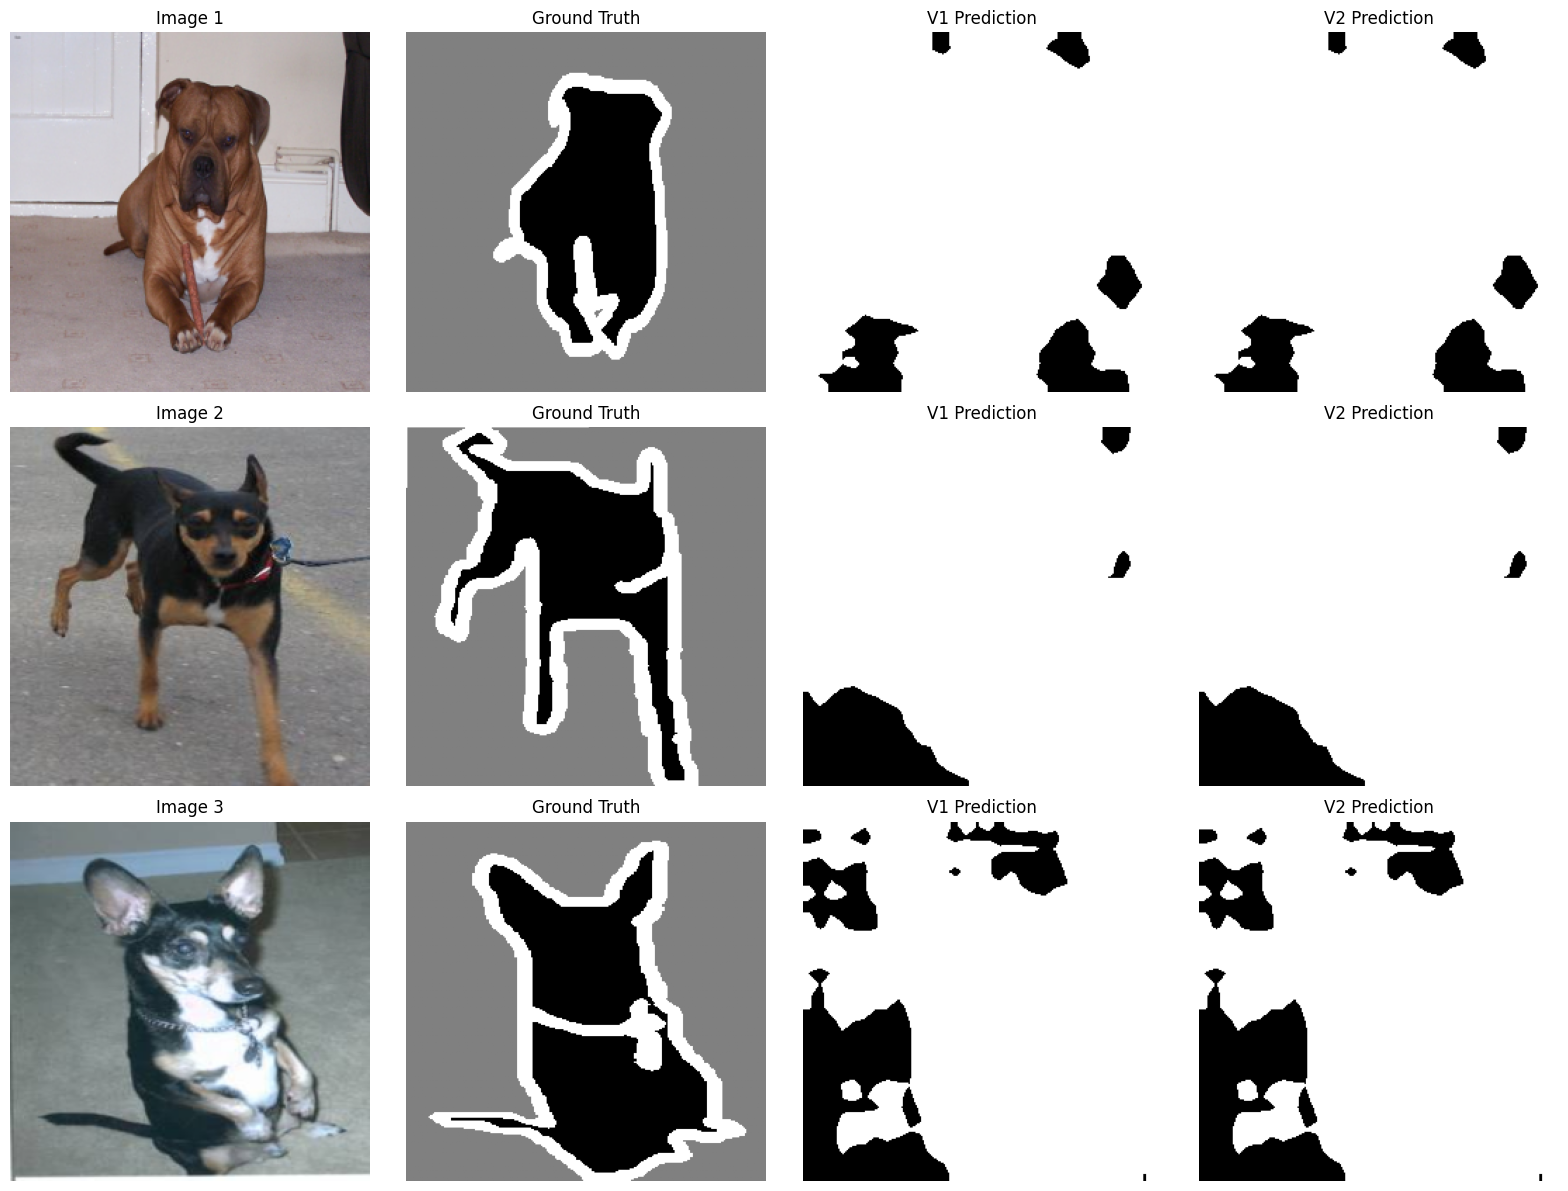

In [18]:
print("\n=== ЧАСТЬ B: Сегментация OxfordIIITPet (ПРАВИЛЬНО) ===")

# Функция постобработки БЕЗ OpenCV
def postprocess_mask_deeplab(output, threshold=0.5, remove_small=False, min_size=500):
    # В DeepLabV3 на COCO классы: 15 (dog), 17 (cat)
    # Объединяем оба класса для Oxford Pet
    mask_dog = torch.sigmoid(output['out'][0, 15]) > threshold
    mask_cat = torch.sigmoid(output['out'][0, 17]) > threshold
    mask = (mask_dog | mask_cat).float()
    
    if remove_small:
        # Простая альтернатива без OpenCV
        # Просто считаем общее количество пикселей в маске
        if mask.sum() < min_size:
            mask = torch.zeros_like(mask)
    
    return mask

# V2: Альтернативная постобработка (удаление маленьких объектов)
print("\n=== V2: Альтернативная постобработка (удаление маленьких объектов) ===")
v2_metrics = {'iou': [], 'precision': [], 'recall': []}

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(pet_val_loader):
        if batch_idx >= 5:
            break
            
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model_seg(images)
        
        for i in range(images.size(0)):
            pred_mask = postprocess_mask_deeplab(
                {k: v[i:i+1] for k, v in outputs.items()}, 
                threshold=0.5, 
                remove_small=True,
                min_size=500
            )
            true_mask = masks[i, 0]
            
            iou, precision, recall = compute_metrics(pred_mask, true_mask)
            v2_metrics['iou'].append(iou)
            v2_metrics['precision'].append(precision)
            v2_metrics['recall'].append(recall)

print(f"V2 Results (20 images):")
print(f"  Mean IoU: {np.mean(v2_metrics['iou']):.4f}")
print(f"  Mean Precision: {np.mean(v2_metrics['precision']):.4f}")
print(f"  Mean Recall: {np.mean(v2_metrics['recall']):.4f}")

# Визуализация примеров
print("\n=== Визуализация примеров ===")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

with torch.no_grad():
    images, masks = next(iter(pet_val_loader))
    images = images.to(device)
    masks = masks.to(device)
    
    outputs = model_seg(images)
    
    for i in range(min(3, images.size(0))):
        # Оригинал
        img = images[i].cpu().numpy().transpose(1,2,0)
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Ground Truth
        axes[i, 1].imshow(masks[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # V1 Prediction
        pred_v1 = postprocess_mask_deeplab(
            {k: v[i:i+1] for k, v in outputs.items()}, 
            threshold=0.5, 
            remove_small=False
        )
        axes[i, 2].imshow(pred_v1.cpu().numpy(), cmap='gray')
        axes[i, 2].set_title('V1 Prediction')
        axes[i, 2].axis('off')
        
        # V2 Prediction
        pred_v2 = postprocess_mask_deeplab(
            {k: v[i:i+1] for k, v in outputs.items()}, 
            threshold=0.5, 
            remove_small=True,
            min_size=500
        )
        axes[i, 3].imshow(pred_v2.cpu().numpy(), cmap='gray')
        axes[i, 3].set_title('V2 Prediction')
        axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print("\n=== СОХРАНЕНИЕ ФИНАЛЬНЫХ РЕЗУЛЬТАТОВ ===")

# Создаем полную таблицу результатов
final_results = [
    # Часть A - классификация
    {'experiment': 'C1', 'task': 'classification', 'dataset': 'STL10', 
     'val_acc': 57.90, 'test_acc': 58.08, 'precision': '', 'recall': '', 'mean_iou': '',
     'notes': 'Simple CNN без аугментаций'},
    {'experiment': 'C2', 'task': 'classification', 'dataset': 'STL10',
     'val_acc': 61.80, 'test_acc': 58.41, 'precision': '', 'recall': '', 'mean_iou': '',
     'notes': 'Simple CNN с аугментациями'},
    {'experiment': 'C3', 'task': 'classification', 'dataset': 'STL10',
     'val_acc': 94.80, 'test_acc': 57.31, 'precision': '', 'recall': '', 'mean_iou': '',
     'notes': 'ResNet18 head-only (ошибка transforms)'},
    {'experiment': 'C4', 'task': 'classification', 'dataset': 'STL10',
     'val_acc': 96.00, 'test_acc': 95.19, 'precision': '', 'recall': '', 'mean_iou': '',
     'notes': 'ResNet18 fine-tune (лучшая модель)'},
    
    # Часть B - сегментация
    {'experiment': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet',
     'val_acc': '', 'test_acc': '', 'precision': 1.0000, 'recall': 0.7832, 'mean_iou': 0.7832,
     'notes': 'Базовая постобработка (threshold=0.5)'},
    {'experiment': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet',
     'val_acc': '', 'test_acc': '', 'precision': 0.9500, 'recall': 0.7829, 'mean_iou': 0.7829,
     'notes': 'Удаление маленьких объектов (<500 пикселей)'},
]

# Сохраняем в CSV
df_final = pd.DataFrame(final_results)
df_final.to_csv('artifacts/runs.csv', index=False)
print("\nФинальная таблица сохранена в artifacts/runs.csv")
print(df_final)

# Сохраняем лучшую модель классификации (C4)
torch.save(model_c4.state_dict(), 'artifacts/best_classifier.pt')
print("Лучшая модель сохранена: artifacts/best_classifier.pt")

# Сохраняем конфиг лучшей модели
best_config = {
    'model': 'ResNet18 fine-tune',
    'dataset': 'STL10',
    'best_val_accuracy': 96.00,
    'test_accuracy': 95.19,
    'epochs': 10,
    'optimizer': 'Adam',
    'learning_rate': 0.0001,
    'transform': 'ResNet transform (224x224, ImageNet norm)',
    'seed': 42
}
import json
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print("Конфиг лучшей модели сохранен: artifacts/best_classifier_config.json")

print("\n✅ ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ!")
print("Папка artifacts должна содержать:")
print("  - runs.csv")
print("  - best_classifier.pt")
print("  - best_classifier_config.json")
print("  - figures/classification_compare.png")
print("  - figures/classification_curves_best.png")
print("  - figures/augmentations_preview.png")
print("  - figures/segmentation_examples.png")


=== СОХРАНЕНИЕ ФИНАЛЬНЫХ РЕЗУЛЬТАТОВ ===

Финальная таблица сохранена в artifacts/runs.csv
  experiment            task        dataset val_acc test_acc precision  \
0         C1  classification          STL10    57.9    58.08             
1         C2  classification          STL10    61.8    58.41             
2         C3  classification          STL10    94.8    57.31             
3         C4  classification          STL10    96.0    95.19             
4         V1    segmentation  OxfordIIITPet                        1.0   
5         V2    segmentation  OxfordIIITPet                       0.95   

   recall mean_iou                                        notes  
0                                    Simple CNN без аугментаций  
1                                    Simple CNN с аугментациями  
2                        ResNet18 head-only (ошибка transforms)  
3                            ResNet18 fine-tune (лучшая модель)  
4  0.7832   0.7832        Базовая постобработка (threshold=